In [59]:
import torch 
import torch.nn as nn
import torch.nn.functional as F 
device='cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device} device")
block_size=8
batch_size=4
n_embd=384
learning_rate=3e-3 
eval_iters=250
embedding_vector_size=[0.9,0.8]
n_layer=4

Using cpu device


In [6]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [31]:
with open ('/content/drive/MyDrive/pg22566.txt', 'r', encoding="utf-8") as f:
    text = f.read()
print(len(text))

252022


In [30]:
from pathlib import Path
text = Path("pg22566.txt").read_text(encoding="utf-8")
print(len(text))

FileNotFoundError: [Errno 2] No such file or directory: 'pg22566.txt'

In [60]:
print(text[:200])

The Project Gutenberg eBook of Dorothy and the Wizard in Oz
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no rest


In [61]:
chars=sorted(set(text))
print(chars)

['\n', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '—', '‘', '’', '“', '”', '•', '™', '\ufeff']


In [62]:
print(len(chars))

92


In [63]:
string_to_int = {ch:i for i, ch in enumerate(chars)}
int_to_string = {i:ch for i, ch in enumerate(chars)}
encode=lambda s: [string_to_int[c] for c in s]
decode=lambda l: ''.join([int_to_string[i] for i in l])
print(encode("hello world"))
print(decode(encode("hello world")))


[65, 62, 69, 69, 72, 1, 80, 72, 75, 69, 61]
hello world


In [65]:
data=torch.tensor(encode(text),dtype=torch.long)
print(data[:100])

tensor([91, 48, 65, 62,  1, 44, 75, 72, 67, 62, 60, 77,  1, 35, 78, 77, 62, 71,
        59, 62, 75, 64,  1, 62, 30, 72, 72, 68,  1, 72, 63,  1, 32, 72, 75, 72,
        77, 65, 82,  1, 58, 71, 61,  1, 77, 65, 62,  1, 51, 66, 83, 58, 75, 61,
         1, 66, 71,  1, 43, 83,  0,  1,  1,  1,  1,  0, 48, 65, 66, 76,  1, 62,
        59, 72, 72, 68,  1, 66, 76,  1, 63, 72, 75,  1, 77, 65, 62,  1, 78, 76,
        62,  1, 72, 63,  1, 58, 71, 82, 72, 71])


In [66]:
n=int(0.8*len(data))
train_data=data[:n]
val_data=data[n:]
def get_batch(split):
    data=train_data if split=='train' else val_data
    ix=torch.randint(len(data)-block_size,(batch_size,))
    x=torch.stack([data[i:i+block_size] for i in ix])
    y=torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x.to(device),y.to(device)
x,y=get_batch('train')
print('inputs:')
print(x.shape)
print(x)
print('targets:')
print(y.shape)
print(y)

inputs:
torch.Size([4, 8])
tensor([[62, 61,  1, 65, 66, 76,  1, 70],
        [58, 76, 82,  1, 77, 72,  1, 63],
        [66, 77, 77, 62, 75, 69, 82, 12],
        [ 1, 63, 66, 71, 61,  1, 76, 72]])
targets:
torch.Size([4, 8])
tensor([[61,  1, 65, 66, 76,  1, 70, 58],
        [76, 82,  1, 77, 72,  1, 63, 72],
        [77, 77, 62, 75, 69, 82, 12,  1],
        [63, 66, 71, 61,  1, 76, 72, 70]])


In [67]:
block_size=8
x=train_data[:block_size]
y=train_data[1:block_size+1]
for t in range(block_size):
    context=x[:t+1]
    target=y[:t+1]
    print(f"when input is {context} the target is {target}")

when input is tensor([91]) the target is tensor([48])
when input is tensor([91, 48]) the target is tensor([48, 65])
when input is tensor([91, 48, 65]) the target is tensor([48, 65, 62])
when input is tensor([91, 48, 65, 62]) the target is tensor([48, 65, 62,  1])
when input is tensor([91, 48, 65, 62,  1]) the target is tensor([48, 65, 62,  1, 44])
when input is tensor([91, 48, 65, 62,  1, 44]) the target is tensor([48, 65, 62,  1, 44, 75])
when input is tensor([91, 48, 65, 62,  1, 44, 75]) the target is tensor([48, 65, 62,  1, 44, 75, 72])
when input is tensor([91, 48, 65, 62,  1, 44, 75, 72]) the target is tensor([48, 65, 62,  1, 44, 75, 72, 67])


In [68]:
x=train_data[:block_size]
y=train_data[1:block_size+1]
for t in range(block_size):
    context=x[:t+1]
    target=y[:t+1]
    print(f"when input is {context} the target is {target}")

when input is tensor([91]) the target is tensor([48])
when input is tensor([91, 48]) the target is tensor([48, 65])
when input is tensor([91, 48, 65]) the target is tensor([48, 65, 62])
when input is tensor([91, 48, 65, 62]) the target is tensor([48, 65, 62,  1])
when input is tensor([91, 48, 65, 62,  1]) the target is tensor([48, 65, 62,  1, 44])
when input is tensor([91, 48, 65, 62,  1, 44]) the target is tensor([48, 65, 62,  1, 44, 75])
when input is tensor([91, 48, 65, 62,  1, 44, 75]) the target is tensor([48, 65, 62,  1, 44, 75, 72])
when input is tensor([91, 48, 65, 62,  1, 44, 75, 72]) the target is tensor([48, 65, 62,  1, 44, 75, 72, 67])


In [70]:
class Block(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.ln=nn.LayerNorm(n_embd)
        self.ff=nn.Sequential(
            nn.Linear(n_embd,4*n_embd),
            nn.ReLU(),
            nn.Linear(4*n_embd,n_embd),
        )
    def forward(self,x):
        return x+self.ff(self.ln(x))

class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size, n_embd):
        super().__init__()
        self.token_embedding_table=nn.Embedding(vocab_size,n_embd)
        self.position_embedding_table=nn.Embedding(block_size,n_embd)
        self.blocks=nn.Sequential(*[Block(n_embd) for _ in range(n_layer)])
        self.ln_f=nn.LayerNorm(n_embd)
        self.lm_head=nn.Linear(n_embd,vocab_size)
    def forward(self, idx, targets=None):
        B,T=idx.shape
        token_emb=self.token_embedding_table(idx)
        pos_emb=self.position_embedding_table(torch.arange(T,device=idx.device))
        x=token_emb+pos_emb
        x=self.blocks(x)
        x=self.ln_f(x)
        logits=self.lm_head(x)
        if targets is None:
            loss=None
        else:
            B,T,C=logits.shape
            logits=logits.view(B*T,C)
            targets=targets.view(B*T)
            loss=F.cross_entropy(logits,targets)
        return logits,loss
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond=idx[:, -block_size:]
            logits, _ = self.forward(idx_cond)
            logits=logits[:,-1,:]
            probs=F.softmax(logits,dim=-1)
            idx_next=torch.multinomial(probs,num_samples=1)
            idx=torch.cat((idx,idx_next),dim=1)
        return idx
    
model=BigramLanguageModel(vocab_size=len(chars), n_embd=n_embd)
m=model.to(device)
context=torch.zeros((1,1),dtype=torch.long,device=device)
generated_chars=model.generate(context,max_new_tokens=500)[0].tolist()
print(generated_chars)

[0, 14, 12, 64, 66, 6, 23, 57, 34, 43, 47, 76, 21, 36, 3, 56, 27, 65, 70, 42, 18, 23, 60, 49, 49, 71, 4, 52, 81, 61, 67, 30, 3, 3, 14, 47, 34, 67, 5, 65, 1, 48, 80, 7, 63, 45, 60, 4, 84, 64, 31, 76, 63, 48, 24, 54, 10, 80, 47, 4, 14, 34, 43, 34, 67, 76, 43, 12, 70, 72, 67, 40, 12, 29, 31, 71, 43, 51, 28, 76, 64, 61, 24, 64, 4, 41, 39, 76, 72, 47, 56, 41, 33, 34, 75, 15, 43, 54, 34, 14, 67, 55, 36, 29, 86, 76, 37, 47, 37, 61, 87, 54, 28, 60, 73, 7, 19, 91, 61, 6, 17, 30, 49, 75, 65, 7, 11, 1, 69, 71, 72, 30, 84, 2, 61, 82, 3, 4, 42, 67, 66, 31, 79, 42, 78, 35, 32, 9, 70, 67, 10, 20, 75, 14, 34, 54, 78, 25, 4, 47, 36, 51, 67, 19, 37, 22, 15, 59, 5, 62, 70, 36, 30, 54, 13, 74, 44, 76, 58, 3, 59, 41, 16, 29, 53, 9, 70, 81, 24, 64, 60, 70, 60, 9, 24, 6, 76, 45, 28, 25, 22, 41, 4, 84, 41, 4, 71, 31, 81, 38, 58, 13, 4, 61, 56, 78, 86, 41, 53, 38, 33, 16, 23, 43, 56, 72, 19, 45, 78, 57, 70, 40, 83, 51, 63, 7, 42, 18, 80, 27, 91, 39, 42, 21, 55, 84, 61, 76, 70, 24, 60, 5, 34, 55, 41, 60, 40, 85

In [ ]:
optim=torch.optim.AdamW(model.parameters(),lr=3e-4)
for i in range(40000):
    xb,yb=get_batch('train')
    logits,loss=model.forward(xb,yb)
    optim.zero_grad(set_to_none=True)
    loss.backward()
    optim.step()
    optim.zero_grad(set_to_none=True)
print(loss.item())

In [56]:
@torch.no_grad()
def estimate_loss(eval_iters=200):
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

losses = estimate_loss()
print(f"train loss: {losses['train']:.4f}")
print(f"val loss: {losses['val']:.4f}")


train loss: 3.2842
val loss: 5.4432


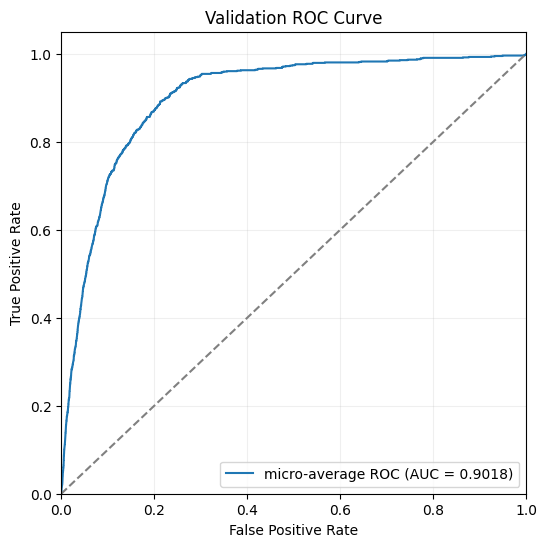

Validation micro-average ROC-AUC: 0.9018


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

@torch.no_grad()
def plot_val_roc_auc(eval_batches=30):
    model.eval()
    y_true_all = []
    y_score_all = []
    vocab_size = len(chars)

    for _ in range(eval_batches):
        X, Y = get_batch("val")
        logits, _ = model(X)
        probs = F.softmax(logits, dim=-1)

        y_true_all.append(Y.reshape(-1).cpu().numpy())
        y_score_all.append(probs.reshape(-1, vocab_size).cpu().numpy())

    model.train()

    y_true = np.concatenate(y_true_all)
    y_score = np.concatenate(y_score_all)

    y_true_bin = label_binarize(y_true, classes=np.arange(vocab_size))
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"micro-average ROC (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Validation ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.2)
    plt.show()

    print(f"Validation micro-average ROC-AUC: {roc_auc:.4f}")

plot_val_roc_auc(eval_batches=30)


In [58]:
context=torch.zeros((1,1),dtype=torch.long,device=device)
generated_chars=model.generate(context,max_new_tokens=500)[0].tolist()
print(decode(generated_chars))


 htte nw esgtth  reroetoieene eestac chhe""
"n,gweia   blmic otweee nn s naed  e   llltchyaa t na fi drfa nta n
  ehvrnl ineeoso

"'reat o gtooghet  hteeee   o yeen  ghhhagt  dn T  oo ennvehoassa hdes at, eh  mpppgnc gcllanhhcknai,,ooaadeesdndao  eo ddeh.a oAll eetlfggpleto ht nylafe rwe.efamm aeft t d
 n pu.

ayulorea  ee  h   a Iiecdd  tad hmthe

,ha    whwo hteppelevemssv 'edeeeelekedrh pmm,ddiemesmbateerw s to,daon  fo   eesprr akrlyye lainryuomaleurwtsnffa rse e  ly.s  IseelfffhJJJJJJJJJJJJ
